## Chapter 4: Implementing a GPT model from scratch for text generation

### 4.1 Coding a LLM Architecture

In [1]:
import torch

print(f"Torch version: {torch.__version__}")
print(f"GPU/CUDA available: {torch.cuda.is_available()}")

Torch version: 2.9.1+cu130
GPU/CUDA available: True


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/02.webp" width="400px">

- Configuration details for the 124 million parameter GPT-2 model as follows:

In [2]:
GPT2_CONFIG_124M = {
    "vocab_size": 50257,            # Vocabulary size
    "contextWindow_len": 1024,      # Context length
    "embedding_dim": 768,           # Embedding dimension
    "num_heads": 12,                # Number of attention heads
    "num_transformerLayers": 12,    # Number of layers
    "dropout_rate": 0.1,            # Dropout rate
    "qkv_bias": False               # Query-Key-Value bias
}

- We use short variable names to avoid long lines of code later
- `"vocab_size"` indicates a vocabulary size of 50,257 words, supported by the BPE tokenizer of GPT2
- `"contextWindow_len"` represents the model's maximum input token count allowed in GPT2, as enabled by positional embeddings 
- `"embedding_dim"` is the embedding size for token inputs, converting each input token into a 768-dimensional vector
- `"num_heads"` is the number of attention heads in the multi-head attention mechanism
- `"num_transformerLayers"` is the number of transformer blocks within the model
- `"dropout_rate"` is the dropout mechanism's intensity, 0.1 means dropping 10% of hidden units during training to mitigate overfitting
- `"qkv_bias"` decides if the `Linear` layers in the multi-head attention mechanism should include a bias vector when computing query (Q), key (K), and value (V) tensors, we'll disable this option which is standard practice in modern LLMs.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/03.webp" width="500px">

In [2]:
import torch.nn as nn
import tiktoken

In [4]:
# Sample model class which defines the bare bone structure of GPT2 without implementing the layers
class DummyGPTModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        # Embedding layers
        self.token_embedding_layer = nn.Embedding(config["vocab_size"], config["embedding_dim"])
        self.position_embedding_layer = nn.Embedding(config["contextWindow_len"], config["embedding_dim"])
        self.dropout_layer = nn.Dropout(config["dropout_rate"])

        # Transformer blocks
        self.transformer_blocks = nn.Sequential(
            *[DummyTransformerBlock(config) for _ in range(config["num_transformerLayers"])]
        )

        # Layer Norm
        self.final_norm = DummyLayerNorm(config["embedding_dim"])
        # layer to convert token ids into text
        # This layer provides a 1xn row matrix for each token id with the highest score given to the position of the text for that token id
        self.output_head = nn.Linear(
            config["embedding_dim"], config["vocab_size"], bias=False
        )

    def forward(self, input_sentence):
        # extracting the number of sentences present in the batch(batch_size) & number of tokens in each sentence(sequence_len)
        batch_size, sequence_len = input_sentence.shape
        token_embeddings = self.token_embedding_layer(input_sentence)
        position_embeddings = self.position_embedding_layer(torch.arange(sequence_len, device=input_sentence.device))
        x = token_embeddings + position_embeddings
        x = self.transformer_blocks(x)
        x = self.final_norm(x)
        logits = self.output_head(x)
        return logits

# placeholder class which returns the input 
class DummyTransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

    def forward(self, x):
        return x

# placeholder class which returns the input
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
    
    def forward(self, x):
        return x

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/04.webp?123" width="500px">

In [5]:
# creating a sample batch for visualizing ouputs 
sentence1 = "Every effort moves you"
sentence2 = "Every day holds a"

sample_batch = []
tokenizer = tiktoken.get_encoding("gpt2")

# add those two input sentence as encoded text to the batch 
sample_batch.append(torch.tensor(tokenizer.encode(sentence1)))
sample_batch.append(torch.tensor(tokenizer.encode(sentence2)))
sample_batch = torch.stack(sample_batch, dim=0)

print(f"The shape of sample batch is {sample_batch.shape} and contains: \n{sample_batch}")

The shape of sample batch is torch.Size([2, 4]) and contains: 
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [6]:
# creating object of sample GPT model which initializes the weight matrices
torch.manual_seed(123)
sample_gptmodel = DummyGPTModel(config=GPT2_CONFIG_124M)

logits = sample_gptmodel(sample_batch)
print(f"The ouput logits is of size {logits.shape} and contains: \n{logits}")

The ouput logits is of size torch.Size([2, 4, 50257]) and contains: 
tensor([[[-1.1947,  0.1392, -0.8616,  ..., -1.4987, -0.0314, -0.4490],
         [ 0.0497,  0.3861, -0.3281,  ..., -0.1826,  1.3084,  0.9867],
         [ 0.7005,  1.4747, -0.4149,  ...,  1.7756, -0.2280,  0.5384],
         [ 0.4885,  1.7545, -0.6707,  ...,  1.1501, -0.1143, -0.9368]],

        [[-1.1947,  0.1392, -0.8616,  ..., -1.4987, -0.0314, -0.4490],
         [-0.5591,  0.5797, -0.1296,  ...,  0.2691,  0.3151,  1.4046],
         [ 0.8524,  1.2833, -0.1786,  ..., -0.1982,  0.1097,  0.2812],
         [-0.0190, -0.8277,  0.2299,  ...,  1.7974, -0.1646, -0.1049]]],
       grad_fn=<UnsafeViewBackward0>)


### 4.2 Normalization of output activations using layer normalization

- Layer normalization, also known as LayerNorm ([Ba et al. 2016](https://arxiv.org/abs/1607.06450)), centers the activations(ouputs of activation layer/linear layer) of a neural network layer around a mean of 0 and normalizes their variance to 1
- This stabilizes training and enables faster convergence to effective weights
- Layer normalization is applied both before and after the multi-head attention module within the transformer block, it's also applied before the final output layer

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/05.webp" width="400px">

In [7]:
torch.manual_seed(123)

# create 2 training examples with 5 dimensions (features) each
example_batch = torch.randn(2, 5)

# creating a sample linear layer with activation function to get input values for layernorm
dummy_layer = nn.Sequential(
    nn.Linear(5, 6),
    nn.ReLU()       # activation function to add non linearity which helps in faster convergence
)

LNexample_input = dummy_layer(example_batch)
print(f"The example input fro layerNorm is: \n{LNexample_input}")

The example input fro layerNorm is: 
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [8]:
# calculating mean and variance of the examples
mean = LNexample_input.mean(dim=-1, keepdim=True)
variance = LNexample_input.var(dim=-1, keepdim=True)

print(f"Mean: \n{mean}\n\nVariance: \n{variance}")

Mean: 
tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)

Variance: 
tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


- The normalization is applied to each of the two inputs (rows) independently; using dim=-1 applies the calculation across the last dimension (in this case, the feature dimension) instead of the row dimension

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/06.webp" width="400px">

In [9]:
output_norm = (LNexample_input - mean) / torch.sqrt(variance)
print(f"Normalized outputs are: \n{output_norm}\n")

norm_mean = output_norm.mean(dim=-1, keepdim=True)
norm_variance = output_norm.var(dim=-1, keepdim=True)
print(f"Mean after normalization: \n{norm_mean}\n\nVariance after normalization: \n{norm_variance}")

Normalized outputs are: 
tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)

Mean after normalization: 
tensor([[9.9341e-09],
        [5.9605e-08]], grad_fn=<MeanBackward1>)

Variance after normalization: 
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [10]:
# printing outputs without scientific mode of pyTorch
torch.set_printoptions(sci_mode=False)
print(f"Mean after normalization: \n{norm_mean}\n\nVariance after normalization: \n{norm_variance}")

Mean after normalization: 
tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)

Variance after normalization: 
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- Subtracting the mean and dividing by the square-root of the variance (standard deviation) centers the inputs to have a mean of 0 and a variance of 1 across the column (feature) dimension which is the desired output of layernorm

In [11]:
# layer normalization class with trainable parameters(weights)
class LayerNorm(nn.Module):
    def __init__(self, embedding_dim, eps=1e-5):
        super().__init__()
        self.eps = eps              # small value to avoid division by zero error while normalizing with variance
        self.scale = nn.Parameter(torch.ones(embedding_dim))
        self.shift = nn.Parameter(torch.zeros(embedding_dim))

    def forward(self, x):
        mean = x.mean(dim = -1, keepdim = True)
        variance = x.var(dim = -1, keepdim = True, unbiased = False)
        norm_output = (x - mean) / torch.sqrt(variance + self.eps)
        return self.scale * norm_output + self.shift

**Scale and shift**

- Note that in addition to performing the normalization by subtracting the mean and dividing by the variance, we added two trainable parameters, a `scale` and a `shift` parameter
- The initial `scale` (multiplying by 1) and `shift` (adding 0) values don't have any effect; however, `scale` and `shift` are trainable parameters that the LLM automatically adjusts during training if it is determined that doing so would improve the model's performance on its training task
- This allows the model to learn appropriate scaling and shifting that best suit the data it is processing
- Note that we also add a smaller value (`eps`) before computing the square root of the variance, this is to avoid division-by-zero errors if the variance is 0

**Biased variance**
- In the variance calculation above, setting `unbiased=False` means using the formula $\frac{\sum_i (x_i - \bar{x})^2}{n}$ to compute the variance where n is the sample size (here, the number of features or columns); this formula does not include Bessel's correction (which uses `n-1` in the denominator), thus providing a biased estimate of the variance 
- For LLMs, where the embedding dimension `n` is very large, the difference between using n and `n-1` is negligible
- However, GPT-2 was trained with a biased variance in the normalization layers, which is why we also adopted this setting for compatibility reasons with the pretrained weights that we will load in later chapters
- `unbiased=False` represents sample statistics and `unbiased=True` represents population statistics

In [12]:
# providing example batch (2 x 5) created 
sample_layerNorm = LayerNorm(embedding_dim = 5)
layerNorm_output = sample_layerNorm(example_batch)

ln_mean = layerNorm_output.mean(dim=-1, keepdim=True)
ln_variance = layerNorm_output.var(dim=-1, keepdim=True, unbiased=False)
print(f"Mean after normalization: \n{ln_mean}\n\nVariance after normalization: \n{ln_variance}")

Mean after normalization: 
tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)

Variance after normalization: 
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [13]:
# providing output of sample linear layer (5 x 6) created above
sample_layerNorm = LayerNorm(embedding_dim = 6)
layerNorm_output = sample_layerNorm(LNexample_input)

ln_mean = layerNorm_output.mean(dim=-1, keepdim=True)
ln_variance = layerNorm_output.var(dim=-1, keepdim=True, unbiased=False)
print(f"Mean after normalization: \n{ln_mean}\n\nVariance after normalization: \n{ln_variance}")

Mean after normalization: 
tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)

Variance after normalization: 
tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)


### 4.3 Implementing feed forward network with GELU activations

- we implement a small neural network submodule that is used as part of the transformer block in LLMs
- Activation functions are used in neural network to introduce non linearity which helps in understanding complex patterns apart from linear patterns
- In deep learning, ReLU (Rectified Linear Unit) activation functions are commonly used due to their simplicity and effectiveness in various neural network architectures
- In LLMs, various other types of activation functions are used beyond the traditional ReLU, two notable examples are GELU (Gaussian Error Linear Unit) and SwiGLU (Swish-Gated Linear Unit)
- GELU and SwiGLU are more complex, smooth activation functions incorporating Gaussian and sigmoid-gated linear units, respectively, offering better performance for deep learning models, unlike the simpler, piecewise linear function of ReLU

- GELU ([Hendrycks and Gimpel 2016](https://arxiv.org/abs/1606.08415)) can be implemented in several ways, the exact version is defined as GELU(x)=x⋅Φ(x), where Φ(x) is the cumulative distribution function of the standard Gaussian distribution.
- In practice, it's common to implement a computationally cheaper approximation: $\text{GELU}(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}} \cdot \left(x + 0.044715 \cdot x^3\right)\right]\right)
$ (the original GPT-2 model was also trained with this approximation)

In [14]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return 0.5 * x * (
            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
                (x + 0.044715 * torch.pow(x, 3))
            )
        )

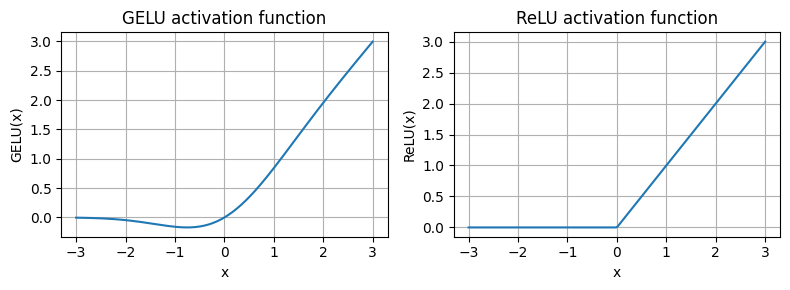

In [15]:
# visualizing the differnece between GELU and ReLU functions
import matplotlib.pyplot as plt

# initiate GELU and ReLU functions
gelu, relu = GELU(), nn.ReLU()

# Sample data between interval [-3, 3]
x = torch.linspace(start=-3, end=3, steps=200)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):     # adding 1 in enumerate object to start i from 1 instead of 0
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel(f"x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()


- From above plot, ReLU is a piecewise linear function that outputs the input directly if it is positive; otherwise, it outputs zero
- GELU is a smooth, non-linear function that approximates ReLU but with a non-zero gradient for negative values (except at approximately -0.75)

- Feed forward network in GPT2 transformer contains 2 linear layers and one GELU activation layer sandwiched between the linear layers

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/10.webp" width="400px">

- The input features are scaled up by a factor of 4 and then scaled down again back to embedding dimension, here the factor is a hyperparameter which can be changed to acheive better outputs


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/09.webp?12" width="400px">

In [16]:
# implementing feed forward network used in transformers
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(config["embedding_dim"], 4*config["embedding_dim"]),
            GELU(),
            nn.Linear(4*config["embedding_dim"], config["embedding_dim"])
        )
    
    def forward(self, x):
        return self.layers(x)

In [17]:
# testing feed forward network in sample data
torch.manual_seed(123)
feedForwardNet = FeedForward(GPT2_CONFIG_124M)

sample_ffn_batch = torch.rand(2, 3, 768)
print(f"Sample input data for FF network is of shape {sample_ffn_batch.shape} and values are: \n{sample_ffn_batch}\n")

ffn_output = feedForwardNet(sample_ffn_batch)
print(f"Feed forward network output is of shape {ffn_output.shape} and values are: \n{ffn_output}")

Sample input data for FF network is of shape torch.Size([2, 3, 768]) and values are: 
tensor([[[0.3501, 0.6816, 0.3673,  ..., 0.7210, 0.7798, 0.6411],
         [0.6069, 0.2349, 0.0628,  ..., 0.8123, 0.3737, 0.8428],
         [0.1043, 0.0533, 0.6490,  ..., 0.8996, 0.3193, 0.6913]],

        [[0.2490, 0.2422, 0.7329,  ..., 0.3954, 0.4880, 0.6910],
         [0.0053, 0.1021, 0.7847,  ..., 0.3044, 0.7911, 0.9492],
         [0.7637, 0.4570, 0.3166,  ..., 0.6247, 0.7798, 0.1691]]])

Feed forward network output is of shape torch.Size([2, 3, 768]) and values are: 
tensor([[[ 0.0139,  0.0136, -0.1403,  ..., -0.2203, -0.1387, -0.0715],
         [-0.0181,  0.0461, -0.1763,  ..., -0.1154, -0.0052,  0.0039],
         [ 0.0301, -0.0376, -0.1168,  ..., -0.1506, -0.1201, -0.1278]],

        [[ 0.0862,  0.0446,  0.0118,  ..., -0.1831, -0.0280, -0.0259],
         [-0.0950,  0.0471, -0.1487,  ..., -0.1297, -0.0834, -0.0053],
         [-0.0161, -0.0762, -0.0622,  ..., -0.0481, -0.0952, -0.1189]]],
       g

In [18]:
print(f"Layers in feed forward network are: \n{feedForwardNet}")

Layers in feed forward network are: 
FeedForward(
  (layers): Sequential(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU()
    (2): Linear(in_features=3072, out_features=768, bias=True)
  )
)


### 4.4 Adding shortcut connections to LLM 

- Shortcut connections are also called skip or residual connections
- Originally, shortcut connections were proposed in deep networks for computer vision (residual networks) to mitigate vanishing gradient problems
- A shortcut connection creates an alternative shorter path for the gradient to flow through the network
- This is achieved by adding the output of one layer to the output of a later layer, usually skipping one or more layers in between
- This acts as a fallback if any layer in sequence is not learning any useful infoemation or gradient vanished for any layer, then input gradient can be fed to the subsequent layers for learning instead of feeding vanished gradient which leads to vanished output(no learning)

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/12.webp?123" width="400px">

In [3]:
class DeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(layer_sizes[0], layer_sizes[1]),
                nn.GELU()
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[1], layer_sizes[2]),
                nn.GELU()
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[2], layer_sizes[3]),
                nn.GELU()
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[3], layer_sizes[4]),
                nn.GELU()
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[4], layer_sizes[5]),
                nn.GELU()
            )
        ])
    
    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # check whether shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = layer_output + x
            else:
                x = layer_output
        return x

In [4]:
# Utility print function to print the gradients of the neural network
def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target and output are
    loss = nn.MSELoss()
    mseloss = loss(output, target)
    
    # Backward pass to calculate the gradients
    mseloss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [5]:
# sample data for the neural network
layer_sizes = [3, 3, 3, 3, 3, 1]

sample_shortcut_input = torch.tensor([1.0, 0.0, -1.0])
print(f"Sample input of size {sample_shortcut_input.shape} is: {sample_shortcut_input}")

Sample input of size torch.Size([3]) is: tensor([ 1.,  0., -1.])


In [6]:
# testing deep neural network without shortcut connections 
torch.manual_seed(123)
model_without_shortcut = DeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_shortcut_input)

layers.0.0.weight has gradient mean of 0.0002017411752603948
layers.1.0.weight has gradient mean of 0.00012011770741082728
layers.2.0.weight has gradient mean of 0.0007152437465265393
layers.3.0.weight has gradient mean of 0.0013988513965159655
layers.4.0.weight has gradient mean of 0.005049604922533035


d:\vscode\generative_AI\build-LLM\.venv\Lib\site-packages\torch\nn\modules\loss.py:634: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [7]:
model_without_shortcut

DeepNeuralNetwork(
  (layers): ModuleList(
    (0-3): 4 x Sequential(
      (0): Linear(in_features=3, out_features=3, bias=True)
      (1): GELU(approximate='none')
    )
    (4): Sequential(
      (0): Linear(in_features=3, out_features=1, bias=True)
      (1): GELU(approximate='none')
    )
  )
)

In [8]:
# testing deep neural network with shortcut connections 
torch.manual_seed(123)
model_with_shortcut = DeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_shortcut_input)

layers.0.0.weight has gradient mean of 0.22186797857284546
layers.1.0.weight has gradient mean of 0.207092747092247
layers.2.0.weight has gradient mean of 0.32923877239227295
layers.3.0.weight has gradient mean of 0.2667771875858307
layers.4.0.weight has gradient mean of 1.3268063068389893


d:\vscode\generative_AI\build-LLM\.venv\Lib\site-packages\torch\nn\modules\loss.py:634: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [9]:
model_with_shortcut

DeepNeuralNetwork(
  (layers): ModuleList(
    (0-3): 4 x Sequential(
      (0): Linear(in_features=3, out_features=3, bias=True)
      (1): GELU(approximate='none')
    )
    (4): Sequential(
      (0): Linear(in_features=3, out_features=1, bias=True)
      (1): GELU(approximate='none')
    )
  )
)

- As we can see based on the output above, shortcut connections prevent the gradients from vanishing in the early layers (towards `layer.0`)

### 4.5 Implementing GPT2 Transformer block

In [24]:
# Multi head attention class (MHA library can also be used)
class MultiHeadAttention(torch.nn.Module):
    def __init__(self, dim_in, dim_out, total_tokens, dropout_rate, num_heads, qkv_bias=False):
        super().__init__()
        assert(dim_out % num_heads == 0), "dim_out must be divisible by num_heads"

        # add the variables to self state that will be used later
        self.d_out = dim_out
        self.num_heads = num_heads
        self.head_dim = dim_out // num_heads    # spliting weight matrix using number of heads (ex: d_out = 4, heads = 2 => then each head will have ..x2 dimension) 

        self.W_queries = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
        self.W_keys = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
        self.W_values = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
        self.projection = torch.nn.Linear(dim_out, dim_out)     # Linear layer to combine head outputs
        self.dropout_layer = torch.nn.Dropout(dropout_rate)
        # registr_buffer is used to register a buffer that should not be considered a model parameter which are arbitary values used for computation
        self.register_buffer('causal_mask', torch.triu(torch.ones(total_tokens, total_tokens), diagonal=1))
    
    def forward(self, x):
        num_batch, num_tokens, dim_in = x.shape
        
        # calculate the q,k,V values w.r.t each input token
        queries = self.W_queries(x)
        keys = self.W_keys(x)
        values = self.W_values(x)

        # implicitly split the matrix by adding a `num_heads` dimension
        # Unroll/reshape last dim: (num_batch, num_tokens, d_out) -> (num_batch, num_tokens, num_heads, head_dim)
        queries = queries.view(num_batch, num_tokens, self.num_heads, self.head_dim)
        keys = keys.view(num_batch, num_tokens, self.num_heads, self.head_dim)
        values = values.view(num_batch, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (num_batch, num_tokens, num_heads, head_dim) -> (num_batch, num_heads, num_tokens, head_dim)
        queries = queries.transpose(1, 2)
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        # Dot product for each head is computed by matrix multiplication of (num_tokens x head_dim) matrices
        attn_scores = queries @ keys.transpose(2, 3)

        # apply causal mask to the attention scores inplace without a variable memory space used
        attn_scores.masked_fill_(
            self.causal_mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        # apply dropout to the attention weights calculated
        attn_weights = self.dropout_layer(attn_weights)

        # calculate context vectores for each input token
        context_vectors = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vectors = context_vectors.contiguous().view(num_batch, num_tokens, self.d_out)
        context_vectors = self.projection(context_vectors)   # optional projection

        return context_vectors

- Modern LLMs only use the decoder from original transformer architecture for generating text
- The transformer decoder contains two blocks: Attention block and Feed forward block 

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/13.webp?1" width="400px">

In [25]:
class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention_layer = MultiHeadAttention(
            dim_in = config["embedding_dim"],
            dim_out = config["embedding_dim"],
            total_tokens = config["contextWindow_len"],
            dropout_rate = config["dropout_rate"],
            num_heads = config["num_heads"],
            qkv_bias = config["qkv_bias"]
        )
        self.layerNorm1 = LayerNorm(config["embedding_dim"], eps = 1e-5)
        self.layerNorm2 = LayerNorm(config["embedding_dim"], eps = 1e-5)
        self.feedForward_layer = FeedForward(config)
        self.dropout_layer = nn.Dropout(config["dropout_rate"])
    
    def forward(self, x):
        # Attention block
        shortcut = x        # Shortcut connection for attention block
        x = self.layerNorm1(x)
        x = self.attention_layer(x)     # Shape [batch_size, num_tokens, emb_size]
        x = self.dropout_layer(x)
        # Add the original input back
        x = x + shortcut

        # Feed Forward block
        shortcut = x        # Shortcut connection for feed forward block
        x = self.layerNorm2(x)
        x = self.feedForward_layer(x)
        x = self.dropout_layer(x)
        x = x + shortcut

        return x

- Suppose we have 2 input samples with 4 tokens each, where each token is a 768-dimensional embedding vector, then this transformer block applies self-attention followed by linear layers to produce an output of similar size

In [26]:
torch.manual_seed(123)

sample_transformer_input = torch.rand(2, 4, 768)
transformerBlock = TransformerBlock(config = GPT2_CONFIG_124M)
transformer_output = transformerBlock(sample_transformer_input)

print(f"The transformer input is of dimensions: {sample_transformer_input.shape}")
print(f"The transformer output is of dimensions: {transformer_output.shape}")

The transformer input is of dimensions: torch.Size([2, 4, 768])
The transformer output is of dimensions: torch.Size([2, 4, 768])


### 4.6 Implementing GPT-2 model

- The transformer block is repeated multiple times in LLMs, for smallest GPT-2 model(124M parameters) it is repeated 12 times

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/15.webp" width="400px">

In [28]:
GPT2_CONFIG_124M = {
    "vocab_size": 50257,            # Vocabulary size
    "contextWindow_len": 1024,      # Context length
    "embedding_dim": 768,           # Embedding dimension
    "num_heads": 12,                # Number of attention heads
    "num_transformerLayers": 12,    # Number of layers
    "dropout_rate": 0.1,            # Dropout rate
    "qkv_bias": False               # Query-Key-Value bias
}

In [29]:
class GPTModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        # Embedding layers
        self.token_embedding_layer = nn.Embedding(config["vocab_size"], config["embedding_dim"])
        self.position_embedding_layer = nn.Embedding(config["contextWindow_len"], config["embedding_dim"])
        self.dropout_layer = nn.Dropout(config["dropout_rate"])

        # Transformer blocks
        self.transformer_blocks = nn.Sequential(
            *[TransformerBlock(config) for _ in range(config["num_transformerLayers"])]
        )

        # Layer Norm
        self.final_norm = LayerNorm(config["embedding_dim"])
        # layer to convert token ids into text
        self.output_head = nn.Linear(
            config["embedding_dim"], config["vocab_size"], bias=False
        )

    def forward(self, input_sentence):
        # extracting the number of sentences present in the batch(batch_size) & number of tokens in each sentence(sequence_len)
        batch_size, sequence_len = input_sentence.shape
        token_embeddings = self.token_embedding_layer(input_sentence)
        position_embeddings = self.position_embedding_layer(torch.arange(sequence_len, device=input_sentence.device))
        x = token_embeddings + position_embeddings
        x = self.transformer_blocks(x)
        x = self.final_norm(x)
        logits = self.output_head(x)
        return logits

In [32]:
# creating a sample batch for visualizing ouputs 
sentence1 = "Every effort moves you"
sentence2 = "Every day holds a"

input_batch = []
tokenizer = tiktoken.get_encoding("gpt2")

# add those two input sentence as encoded text to the batch 
input_batch.append(torch.tensor(tokenizer.encode(sentence1)))
input_batch.append(torch.tensor(tokenizer.encode(sentence2)))
input_batch = torch.stack(input_batch, dim=0)

print(f"The shape of GPT2 input batch is {input_batch.shape} and contains: \n{input_batch}")

The shape of GPT2 input batch is torch.Size([2, 4]) and contains: 
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [33]:
torch.manual_seed(123)

# Instantiating 124M GPT model with random weights
gpt2_124m_model = GPTModel(GPT2_CONFIG_124M)

gpt2_output = gpt2_124m_model(input_batch)

print(f"The output logits of GPT2 model is of dimensions {gpt2_output.shape} and contains: \n{gpt2_output}")

The output logits of GPT2 model is of dimensions torch.Size([2, 4, 50257]) and contains: 
tensor([[[ 0.0286, -0.1171, -0.3106,  ...,  0.0437,  0.2378, -0.6849],
         [ 0.3265, -0.6667, -0.2186,  ..., -0.2369,  0.3896, -0.2350],
         [ 0.7925, -0.1090,  0.3376,  ...,  0.1886, -0.0567, -0.3239],
         [-0.9689,  0.3032, -0.2896,  ...,  1.1436,  0.1990, -0.4704]],

        [[ 0.0020,  0.3344, -0.1001,  ..., -0.0023, -0.0223, -0.5788],
         [ 0.2281, -0.3573, -0.0722,  ...,  0.8808, -0.0775,  0.3793],
         [ 0.8225,  0.9247, -0.0059,  ...,  0.8220,  0.2685,  0.0565],
         [-0.1134, -0.0049,  0.2737,  ...,  1.0374, -0.2007,  0.0892]]],
       grad_fn=<UnsafeViewBackward0>)


In [ ]:
# calculating the number of parameters in the model
total_parameters = sum(p.numel() for p in gpt2_124m_model.parameters())
print(f"The total number of parameters in GPT-2 model is: {total_parameters:,}")

The total number of parameters in GPT-2 model is: 163,009,536


- As we see above, this model has 163M, not 124M parameters
- In the original GPT-2 paper, the researchers applied weight tying/sharing, which means that they reused the token embedding layer (`token_embedding_layer`) as the output layer, which means setting `self.output_head.weight = self.token_embedding_layer.weight`
- The token embedding layer projects the 50,257-dimensional one-hot encoded input tokens to a 768-dimensional embedding representation
- The output layer projects 768-dimensional embeddings back into a 50,257-dimensional representation so that we can convert these back into words 
- So, the embedding and output layer have the same number of weight parameters, as we can see based on the shape of their weight matrices

In [36]:
# weight parameter dimensions of toekn embedding and ouput layer
print(f"The dimesnions of paramters in token embedding layer is: {gpt2_124m_model.token_embedding_layer.weight.shape}")
print(f"The dimensions of parameters in output head layer is: {gpt2_124m_model.output_head.weight.shape}")

The dimesnions of paramters in token embedding layer is: torch.Size([50257, 768])
The dimensions of parameters in output head layer is: torch.Size([50257, 768])


In [38]:
# excluding the count of parameters if weights are shared to get the actual number
weight_shared_parameters = total_parameters - sum(p.numel() for p in gpt2_124m_model.output_head.parameters())
print(f"The total number of parameters in GPT-2 model after weight sharing is: {weight_shared_parameters:,}")

The total number of parameters in GPT-2 model after weight sharing is: 124,412,160


In [40]:
# computing memory requirements for storing the model (assuming stored as float32 with 4 bytes per parameter)
total_bytes = total_parameters * 4

# converting to megabytes
total_mb = total_bytes / (1024 * 1024)

print(f"The total size of the gpt-2 model is: {total_mb:.2f}")

The total size of the gpt-2 model is: 621.83


- Other configurations, which are referenced in the [GPT-2 paper](https://scholar.google.com/citations?view_op=view_citation&hl=en&user=dOad5HoAAAAJ&citation_for_view=dOad5HoAAAAJ:YsMSGLbcyi4C) are:

    - **GPT2-small** (the 124M configuration already implemented):
        - "emb_dim" = 768
        - "n_layers" = 12
        - "n_heads" = 12

    - **GPT2-medium:**
        - "emb_dim" = 1024
        - "n_layers" = 24
        - "n_heads" = 16
    
    - **GPT2-large:**
        - "emb_dim" = 1280
        - "n_layers" = 36
        - "n_heads" = 20
    
    - **GPT2-XL:**
        - "emb_dim" = 1600
        - "n_layers" = 48
        - "n_heads" = 25

In [43]:
# configuration dictionary for other GPT2 models (count considering weight sharing)

# GPT2-medium
GPT2_CONFIG_345M = {
    "vocab_size": 50257,
    "contextWindow_len": 1024,
    "embedding_dim": 1024,
    "num_heads": 16,  
    "num_transformerLayers": 24,
    "dropout_rate": 0.1,
    "qkv_bias": False
}

# GPT2-Large
GPT2_CONFIG_762M = {
    "vocab_size": 50257,
    "contextWindow_len": 1024,
    "embedding_dim": 1280,
    "num_heads": 20,  
    "num_transformerLayers": 36,
    "dropout_rate": 0.1,
    "qkv_bias": False
}

#GPT2-XL
GPT2_CONFIG_1542M = {
    "vocab_size": 50257,
    "contextWindow_len": 1024,
    "embedding_dim": 1600,
    "num_heads": 25,  
    "num_transformerLayers": 48,
    "dropout_rate": 0.1,
    "qkv_bias": False
}

### 4.7 Generating text using GPT-2 model

- LLMs like the GPT model are used to generate one word at a time

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/16.webp" width="400px">

- The following `generate_text_greedy` function implements greedy decoding, which is a simple and fast method to generate text
- In greedy decoding, at each step, the model chooses the word (or token) with the highest probability as its next output (the highest logit corresponds to the highest probability, so we technically wouldn't even have to compute the softmax function explicitly)

- Each token in the output logits contains informatioin about the word/token in next position adn hence the last token in output logits is taken for generating the next token
- The figure below depicts how the GPT model, given an input context, generates the next word token

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/17.webp" width="600px">


In [49]:
def generate_text_greedy(model, input_ids, max_new_tokens, context_window):
    # input_ids is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10 then only the last 5 tokens are used as context
        ids_context_size = input_ids[:, -context_window:]

        with torch.no_grad():
            logits = model(ids_context_size)
        
        # Focus only on the last token
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probabilities = torch.softmax(logits, dim=-1)   # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        next_id = torch.argmax(probabilities, dim=-1, keepdim=True)     # (batch, 1)

        # Append sampled index to the running sequence
        input_ids = torch.cat((input_ids, next_id), dim=-1)   # (batch, n_tokens+1)
        
    return input_ids

- The `generate_text_greedy` above implements an iterative process, where it creates one token at a time

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/18.webp" width="600px">

In [45]:
# sample input for generating text
input_sentence = "Hello, I am"

encoded_text = tokenizer.encode(input_sentence)

print(f"The encoded list is: {encoded_text}")
# convert list into tensor
encoded_tensor = torch.tensor(encoded_text).unsqueeze(0)
print(f"The encoded tensor is of dimensions {encoded_tensor.shape} contains: \n{encoded_tensor}")


The encoded list is: [15496, 11, 314, 716]
The encoded tensor is of dimensions torch.Size([1, 4]) contains: 
tensor([[15496,    11,   314,   716]])


In [51]:
gpt2_124m_model.eval()      # disables dropout

output_ids = generate_text_greedy(
    model = gpt2_124m_model,
    input_ids = encoded_tensor,
    max_new_tokens = 6,
    context_window = GPT2_CONFIG_124M["contextWindow_len"]
)

print(f"The output token ids prodcued is: {output_ids} is of length {len(output_ids[0])}")

The output token ids prodcued is: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]]) is of length 10


In [56]:
# converting the output to list for decoder
output_list = output_ids.squeeze(0).tolist()

decoded_text = tokenizer.decode(output_list)
print(f"The generated text by the LLM is: \n{decoded_text}")

The generated text by the LLM is: 
Hello, I am Featureiman Byeswickattribute argue


- Note that the model is untrained, hence outputs random texts as above